In [2]:
import pandas as pd
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
print(df.shape)

(768, 9)


In [ ]:
# 1. Create a blank canvas of a specific size (Width, Height)
plt.figure(figsize=(6, 4))

# 2. Count the values in the 'Outcome' column and plot them as bars
df['Outcome'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])

# 3. Add labels so it makes sense
plt.title('Count of Diabetic (1) vs Non-Diabetic (0)')
plt.xlabel('Diagnosis Outcome')
plt.ylabel('Number of People')

# 4. Clean up the X-axis labels so they don't look tilted
plt.xticks(rotation=0)

# 5. Render the plot
plt.show()

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
sns.set_theme(style="whitegrid")

In [9]:
features = [col for col in df.columns if col != 'Outcome']

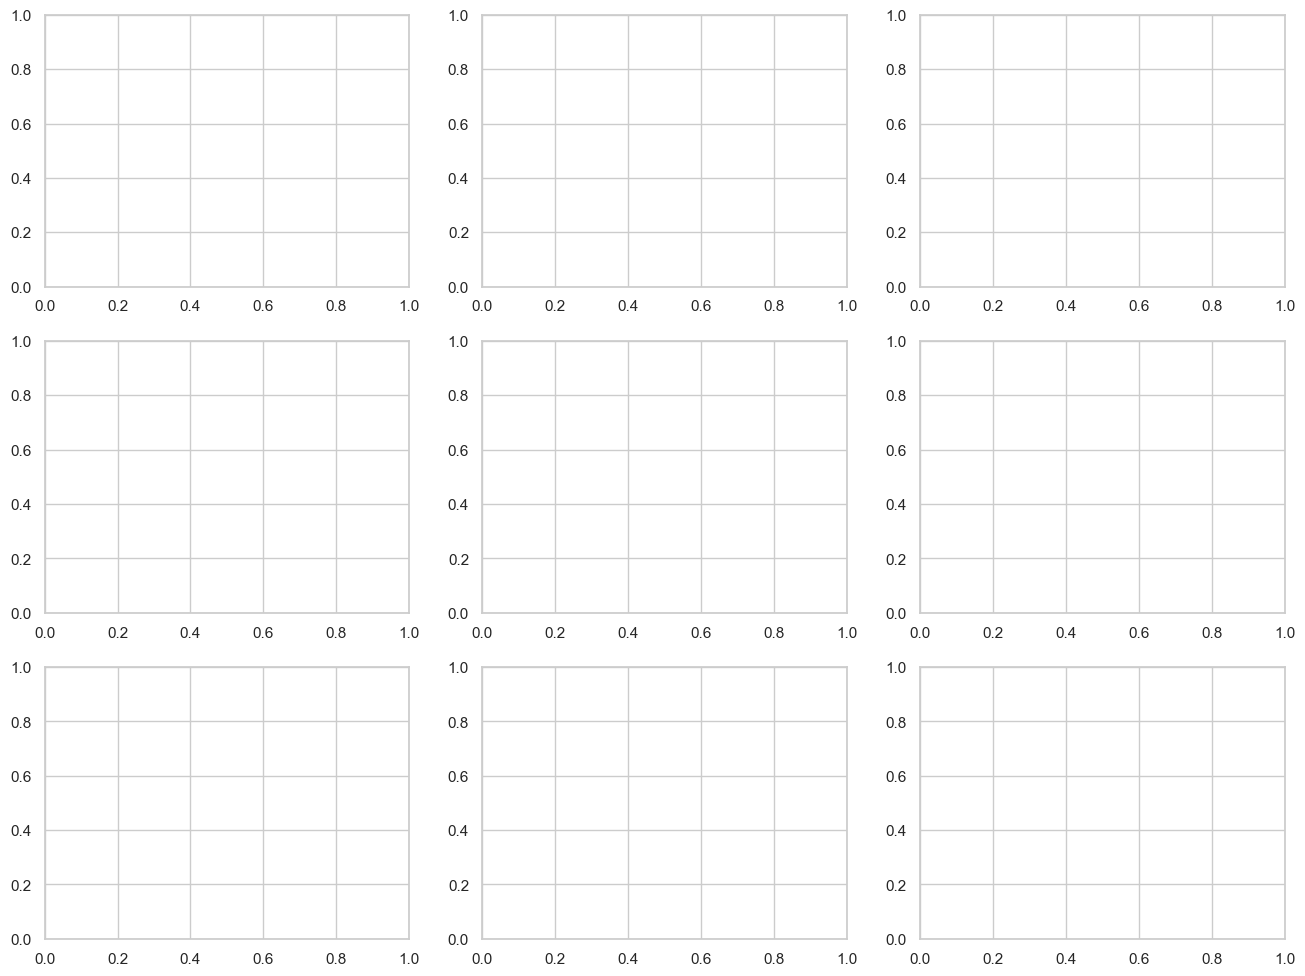

In [10]:
num_charts = len(features)
grid_cols = 3
grid_rows = (num_charts + grid_cols - 1) // grid_cols

fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(16, 4 * grid_rows))
axes = axes.flatten()

In [11]:
for i, col in enumerate(features):
    sns.histplot(
        data=df, 
        x=col, 
        hue='Outcome', 
        multiple='stack',   
        kde=True,           
        ax=axes[i], 
        palette='Set2'      
    )
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')  
    axes[i].set_ylabel('Count')

In [12]:
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

In [13]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

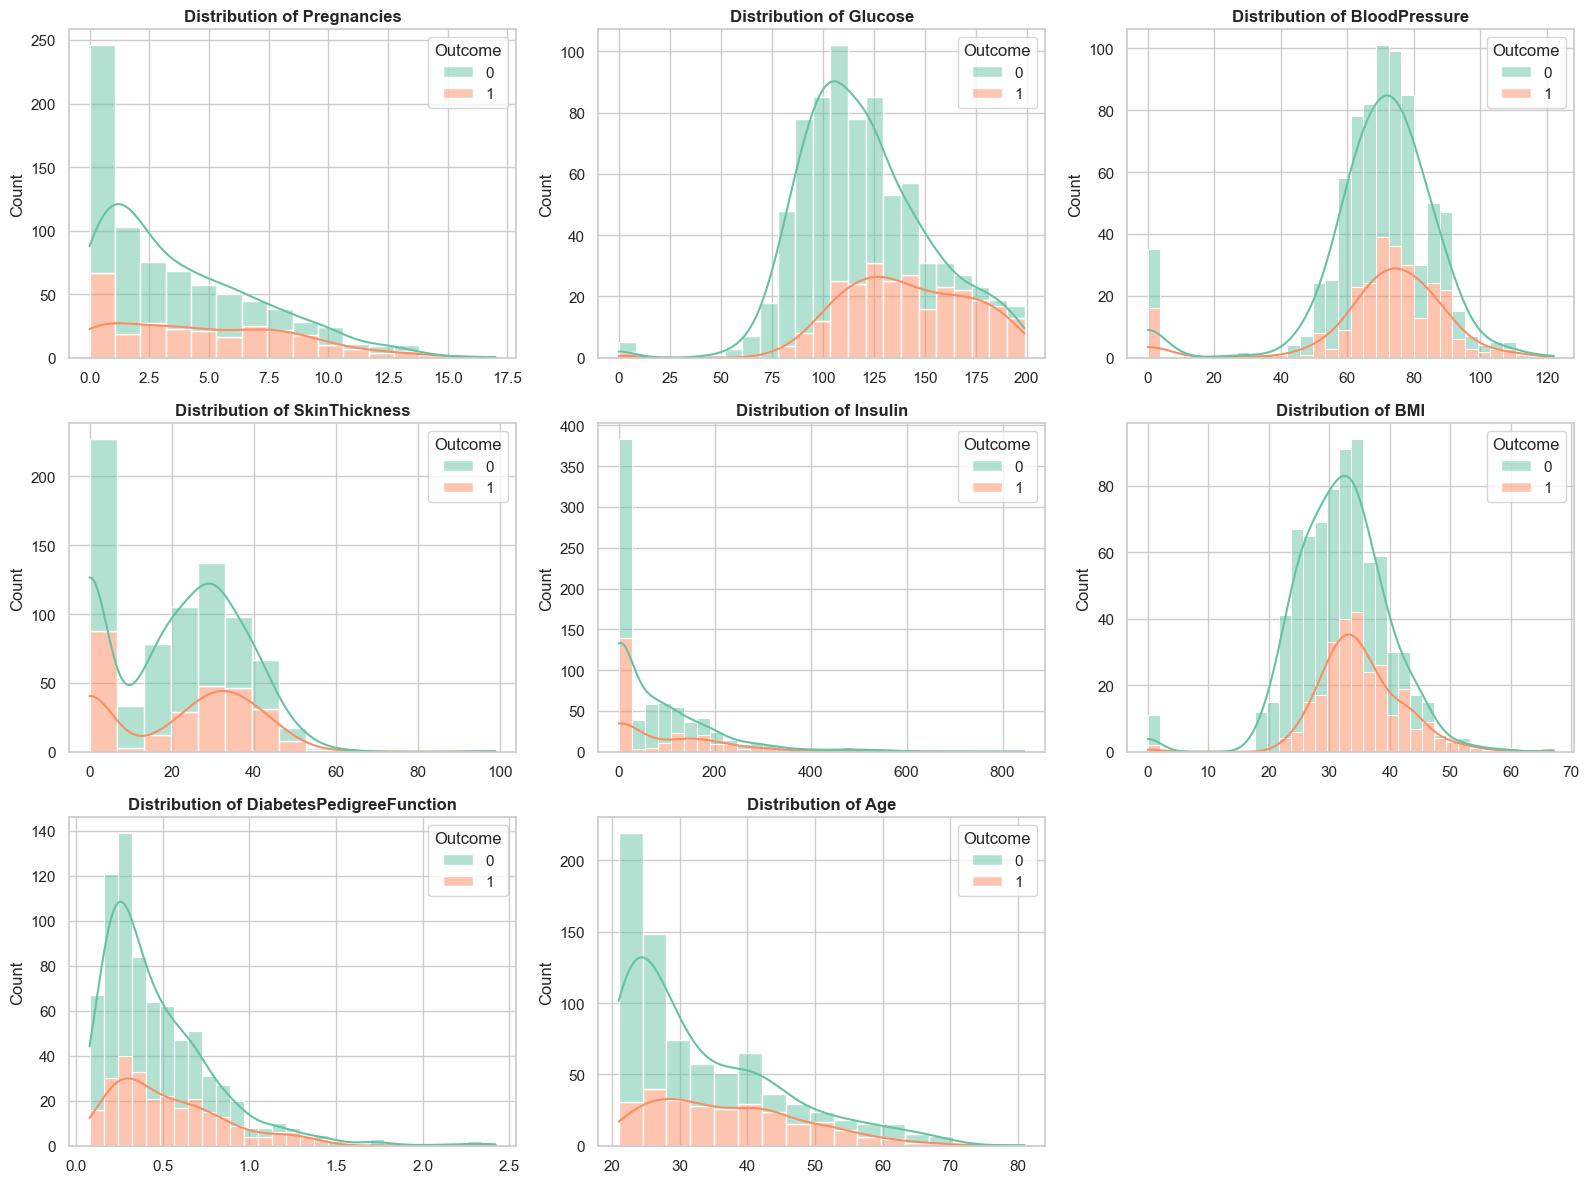

In [14]:
# Create the canvas grid
num_charts = len(features)
grid_cols = 3
grid_rows = (num_charts + grid_cols - 1) // grid_cols

fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(16, 4 * grid_rows))
axes = axes.flatten()

# Loop and draw the graphs
for i, col in enumerate(features):
    sns.histplot(
        data=df, 
        x=col, 
        hue='Outcome', 
        multiple='stack',   
        kde=True,           
        ax=axes[i], 
        palette='Set2'      
    )
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')  
    axes[i].set_ylabel('Count')

# Clean up empty slots and render
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [18]:
import numpy as np

zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in zero_cols:
    df[col] = df[col].replace(0, np.nan)

print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [19]:
for col in zero_cols:
    df[col] = df.groupby('Outcome')[col].transform(lambda x: x.fillna(x.median()))

print(df[zero_cols].isnull().sum())

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


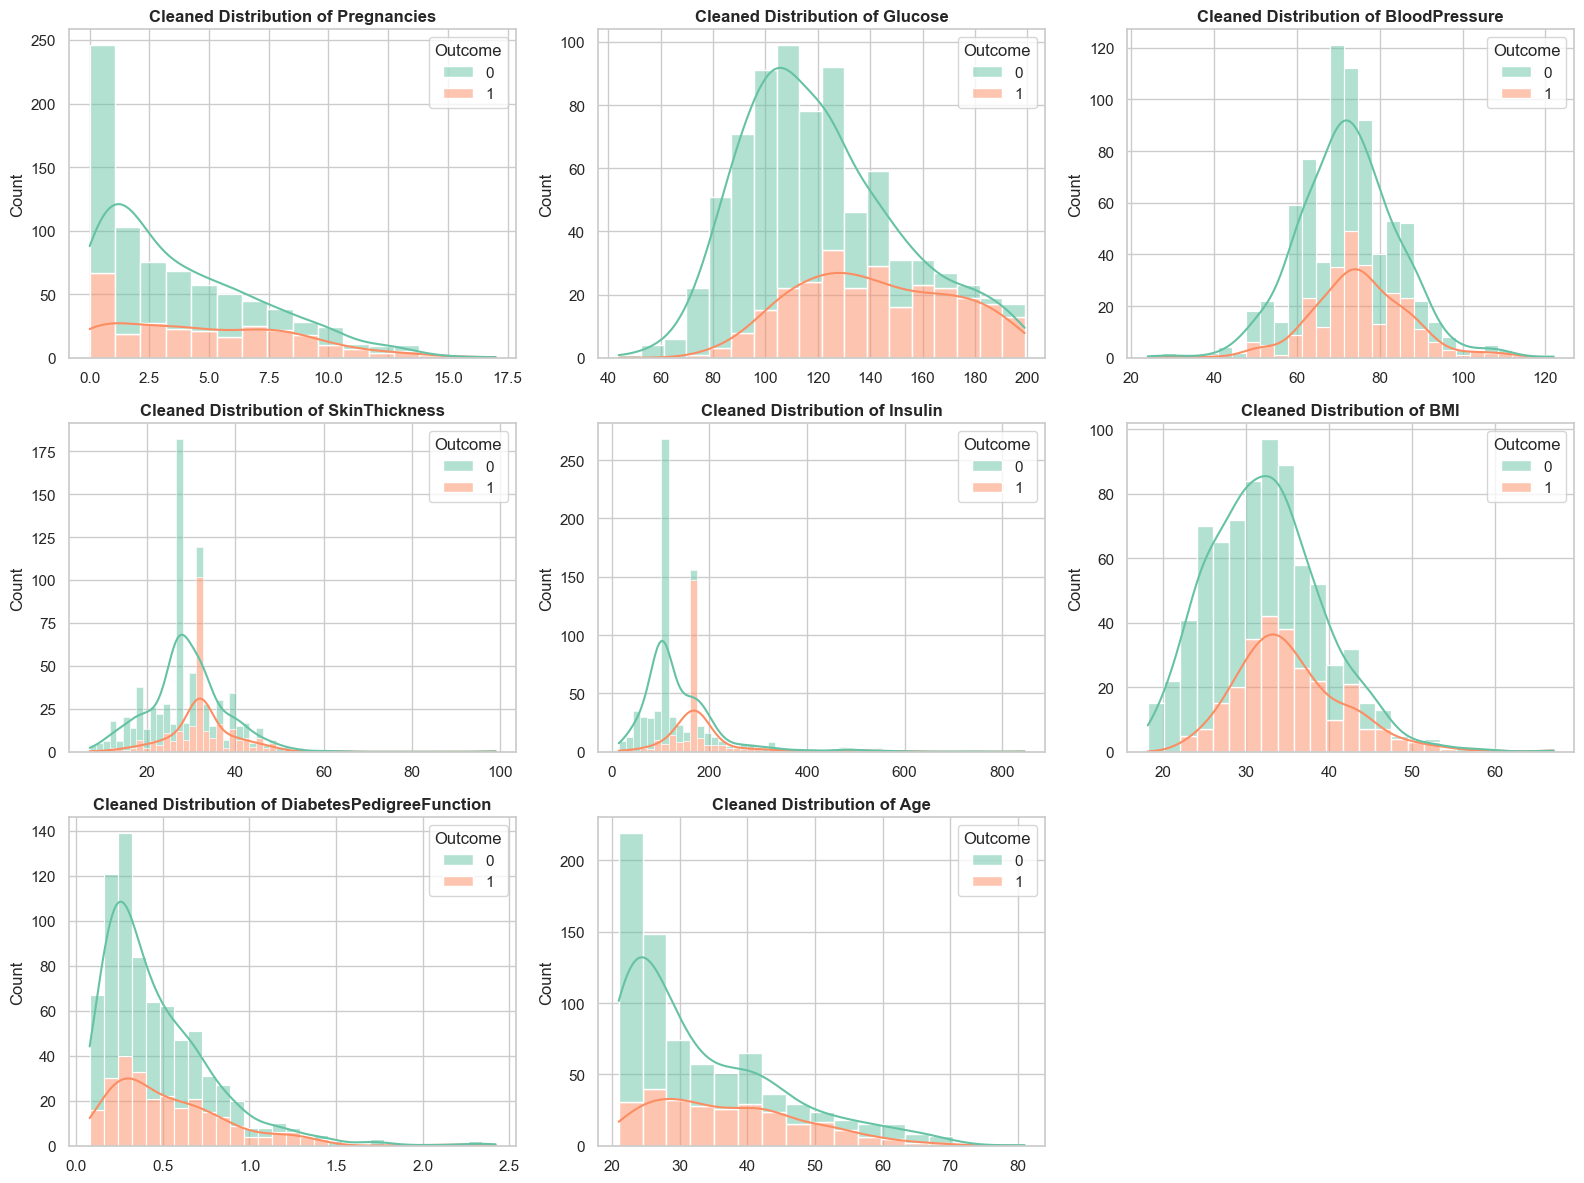

In [21]:
fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(16, 4 * grid_rows))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(
        data=df, 
        x=col, 
        hue='Outcome', 
        multiple='stack',   
        kde=True,           
        ax=axes[i], 
        palette='Set2'      
    )
    axes[i].set_title(f'Cleaned Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')  
    axes[i].set_ylabel('Count')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()